In [2]:
from rdkit import Chem

In [4]:
m1 = Chem.MolFromSmiles('Cc1ccccc1')

In [5]:
m = Chem.MolFromMolFile('data/chiral.mol')

In [8]:
print(Chem.MolToMolBlock(m))


     RDKit          2D

  9  9  0  0  1  0  0  0  0  0999 V2000
    0.0000    2.4750    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7145    2.0625    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.4289    2.4750    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    0.7145    1.2375    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.4289    0.8250    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.4289   -0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7145   -0.4125    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.8250    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  2  1  1  6
  2  3  1  0
  2  4  1  0
  4  5  2  0
  5  6  1  0
  6  7  2  0
  7  8  1  0
  8  9  2  0
  4  9  1  0
M  END



In [16]:
m = Chem.MolFromSmiles('C1OC1')
for a in m.GetAtoms():
    print(a.GetFormalCharge())
for bound in m.GetBonds():
    print(bound.GetBondType())

0
0
0
SINGLE
SINGLE
SINGLE


In [15]:
atom = m.GetAtomWithIdx(0)
[x.GetAtomicNum() for x in atom.GetNeighbors()]

[8, 6]

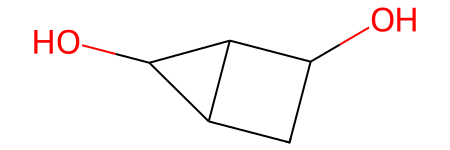

In [22]:
m = Chem.MolFromSmiles('OC1C2C1CC(O)2')
m

In [23]:
ri = m.GetRingInfo()

In [28]:
ri.NumAtomRings(2)
ri.IsAtomInRingOfSize(2,4)

True

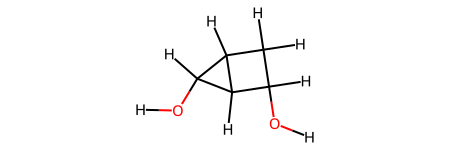

In [30]:
m.GetNumAtoms()
m2 = Chem.AddHs(m)
m2

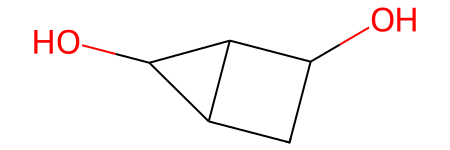

In [32]:
m3 = Chem.RemoveHs(m2)
m3

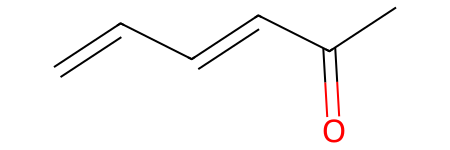

In [34]:
m = Chem.MolFromSmiles('CC(=O)C=CC=C')
m

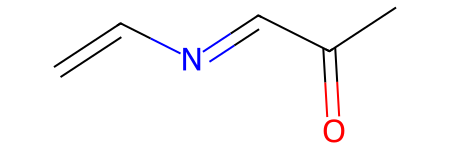

In [40]:
mw = Chem.RWMol(m)
mw.ReplaceAtom(4,Chem.Atom(7))
mw

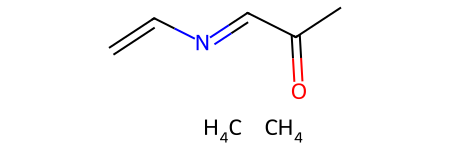

In [41]:
mw.AddAtom(Chem.Atom(6))
mw.AddAtom(Chem.Atom(6))
mw

In [42]:
mw.AddBond(6,7,Chem.BondType.SINGLE)
mw.AddBond(7,8,Chem.BondType.DOUBLE)
mw.AddBond(8,3,Chem.BondType.SINGLE)

9

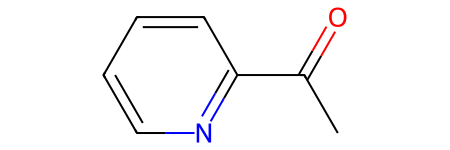

In [43]:
mw

In [54]:
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
m = Chem.MolFromSmiles('C1CCC1OC')
m1=Chem.AddHs(m)
AllChem.EmbedMolecule(m1)
AllChem.MMFFOptimizeMolecule(m1)
AllChem.UFFOptimizeMolecule(m1)

0

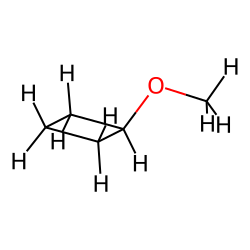

In [55]:
Draw.MolToImage(m1,size=(250,250))

In [48]:
AllChem.Compute2DCoords(m1)

0

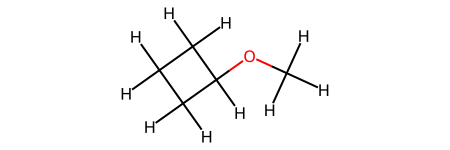

In [49]:
m1

In [57]:
m = Chem.MolFromSmiles('C1CCC1OC')
m1 = Chem.AddHs(m)
AllChem.EmbedMultipleConfs(m1, numConfs=10)
rmslist = []
AllChem.AlignMolConformers(m1, RMSlist=rmslist)
print(rmslist)
AllChem.GetConformerRMS(m1, 0, 9, prealigned=True)

[1.1950826693424612, 1.260680876273483, 1.2503586617652451, 1.3610332746049587, 1.1828855814635106, 1.3598841437290474, 0.6515591598397713, 1.3789151247255904, 0.9328133272138243]


np.float64(0.9328133272138304)

In [59]:
res = AllChem.MMFFOptimizeMoleculeConfs(m1)
res

[(0, 10.72883057753733),
 (0, 11.677582320261102),
 (0, 10.728830577919085),
 (0, 10.728830578281599),
 (0, 10.728830579218979),
 (0, 10.728830577581794),
 (0, 10.728830579142102),
 (0, 10.728830577319616),
 (0, 10.728830578605521),
 (0, 10.728830577516662)]

In [60]:
from rdkit import DataStructs
from rdkit.Chem.Fingerprints import FingerprintMols
ms = [Chem.MolFromSmiles('CCOC'), Chem.MolFromSmiles('CCO')]
fps = [FingerprintMols.FingerprintMol(x) for x in ms]
#计算每个分子的指纹
DataStructs.FingerprintSimilarity(fps[0], fps[1]) #比较相似性

0.6

In [62]:
from rdkit.Chem import MACCSkeys
fps = [MACCSkeys.GenMACCSKeys(x) for x in ms]
DataStructs.FingerprintSimilarity(fps[0], fps[1])

0.5

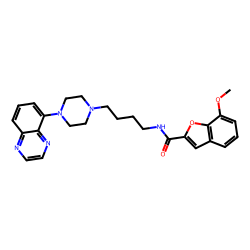

In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem
mol = Chem.MolFromSmiles('COc1cccc2cc(C(=O)NCCCCN3CCN(c4cccc5nccnc54)CC3)oc21')
from rdkit.Chem import Draw
Draw.MolToImage(mol,size=(250,250))

In [3]:
mol = [Chem.MolFromSmiles("c1(C=O)cc(OC)c(O)cc1"),Chem.MolFromSmiles('O=C(NCc1cc(OC)c(O)cc1)CCCC/C=C/C(C)C'),Chem.MolFromSmiles('CC(C)CCCCCC(=O)NCC1=CC(=C(C=C1)O)OC')]
from rdkit.Chem import rdFMCS
res = rdFMCS.FindMCS(mol)
print(res.numAtoms)
Chem.MolToSmiles (res.queryMol)

10


'*~*~*1~*~*(~*)~*~*~*~1~*'

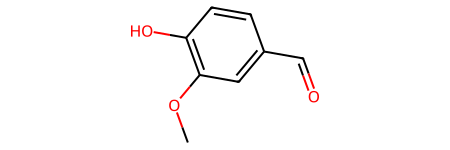

In [69]:
mol[0]

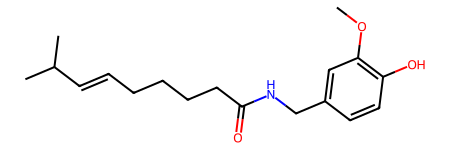

In [70]:
mol[1]

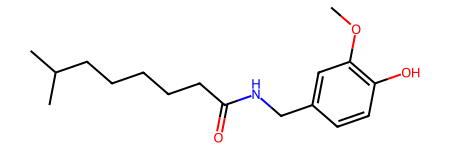

In [71]:
mol[2]

In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem

suppl = Chem.SDMolSupplier('data/cdk2.sdf')
writer = Chem.SDWriter('CDK2_3D.sdf')

for mol in suppl:
    if mol is None: continue
    
    mol = Chem.AddHs(mol)
    
    param = AllChem.ETKDGv3()
    AllChem.EmbedMultipleConfs(mol, numConfs=10, params=param)
    
    AllChem.MMFFOptimizeMoleculeConfs(mol)
    
    for conf in mol.GetConformers():
        writer.write(mol, confId=conf.GetId())

writer.close()